# DOPPLER SCATT PRE-PROCESSING

In [2]:
from smode_import import *

In [3]:
# Load DopplerScatt Data
workdir='/Users/elise/ocean/drifters_chl/'
folder='/Users/elise/data/SMODE-data/DopplerScatt/'
files = sorted(glob(folder+'SMODE_IOP2*.nc'))

dChldt=xr.open_dataset('dChldt_sorted.nc')

# geostrophic
folder='/Users/elise/data/'
geos  = xr.open_dataset(folder+'cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.25deg_P1D_1711053566224.nc')
geos  = geos.sel(latitude=slice(30,40),longitude=slice(-127,-121))

In [4]:
def compute_divergence(u,v,x,y):

    du_dx = np.ones_like(u)*np.nan
    dv_dy = np.ones_like(v)*np.nan

    du_dx[:,1:-1] = (u[:,2:]-u[:,:-2])/(x[:,2:]-x[:,:-2])
    dv_dy[1:-1,:] = (v[2:,:]-v[:-2,:])/(y[2:,:]-y[:-2,:])

    div = du_dx + dv_dy

    return div

def compute_vorticity(u,v,x,y):
    
    du_dy = np.ones_like(u)*np.nan
    dv_dx = np.ones_like(v)*np.nan
    
    du_dy[1:-1:,:] = (u[2:,:]-u[:-2,:])/(y[2:,:]-y[:-2,:])
    dv_dx[:,1:-1] = (v[:,2:]-v[:,:-2])/(x[:,2:]-x[:,:-2])
    
    vor = dv_dx - du_dy

    return vor

In [11]:
def okubo_weiss(u, v, x, y):
    # W = s_n^2 + s_s^2 - omega^2
    
    # Compute velocity gradients
    du_dx = np.ones_like(u)*np.nan
    dv_dy = np.ones_like(v)*np.nan
    du_dy = np.ones_like(u)*np.nan
    dv_dx = np.ones_like(v)*np.nan
    
    du_dy[1:-1:,:] = (u[2:,:]-u[:-2,:])/(y[2:,:]-y[:-2,:])
    dv_dx[:,1:-1] = (v[:,2:]-v[:,:-2])/(x[:,2:]-x[:,:-2])
    du_dx[:,1:-1] = (u[:,2:]-u[:,:-2])/(x[:,2:]-x[:,:-2])
    dv_dy[1:-1,:] = (v[2:,:]-v[:-2,:])/(y[2:,:]-y[:-2,:])
    
    # Compute Okubo-Weiss components
    sn = du_dx - dv_dy         # normal strain
    ss = dv_dx + du_dy         # shear strain
    zeta = dv_dx - du_dy       # relative vorticity
    
    # Okubo-Weiss parameter
    W = sn**2 + ss**2 - zeta**2

    return W

In [12]:
def kinematics(dopplerscatt):
    # Smooth the input data first
    # We're using a 2D gaussian filter with a standard deviation based 
    # on the full width half max at the desired "resolution"
    delta_in = 200
    delta_out = 2000
    
    sigma_out = delta_out/np.sqrt(2*np.log(2))/2/delta_in
    u_smoothed = scipy.ndimage.gaussian_filter(dopplerscatt.u_current_all_lines.values,sigma_out)
    v_smoothed = scipy.ndimage.gaussian_filter(dopplerscatt.v_current_all_lines.values,sigma_out)
    
    # The DopplerScatt data is already on an x/y UTM grid, so we can easily 
    # compute the derivatives using those coordinates.
    x_mesh,y_mesh = np.meshgrid(dopplerscatt.x.values,dopplerscatt.y.values)
    divergence = compute_divergence(u_smoothed,v_smoothed,x_mesh,y_mesh)
    vorticity  = compute_vorticity(u_smoothed,v_smoothed,x_mesh,y_mesh)
    W = okubo_weiss(u_smoothed,v_smoothed,x_mesh,y_mesh)
    
    return W, divergence, vorticity
    

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)
/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)


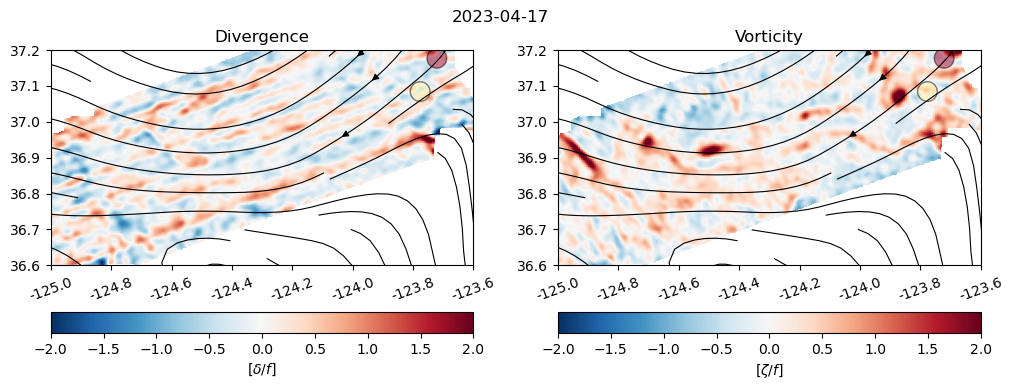

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)
/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)


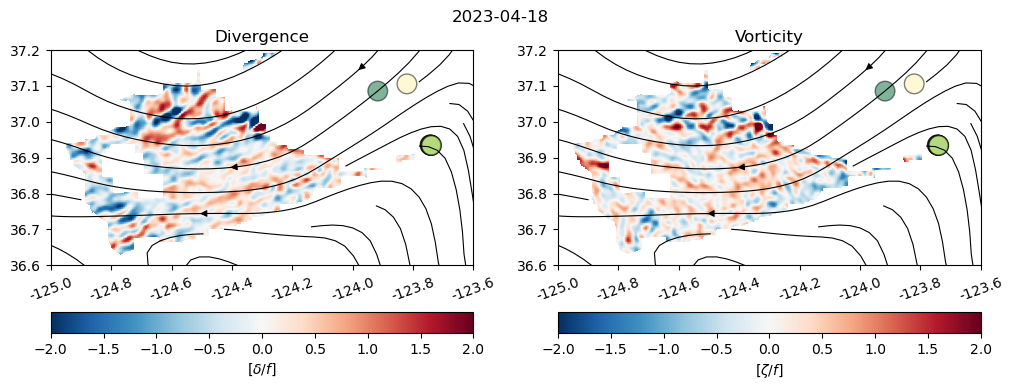

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)
/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)


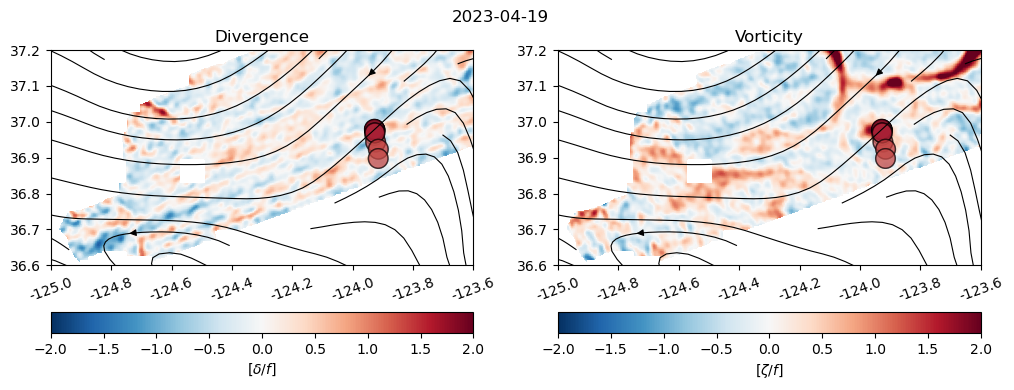

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)
/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)


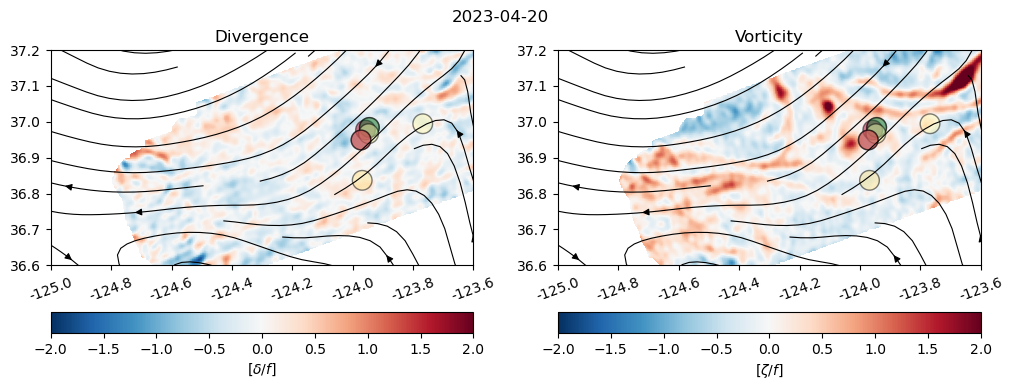

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)
/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)


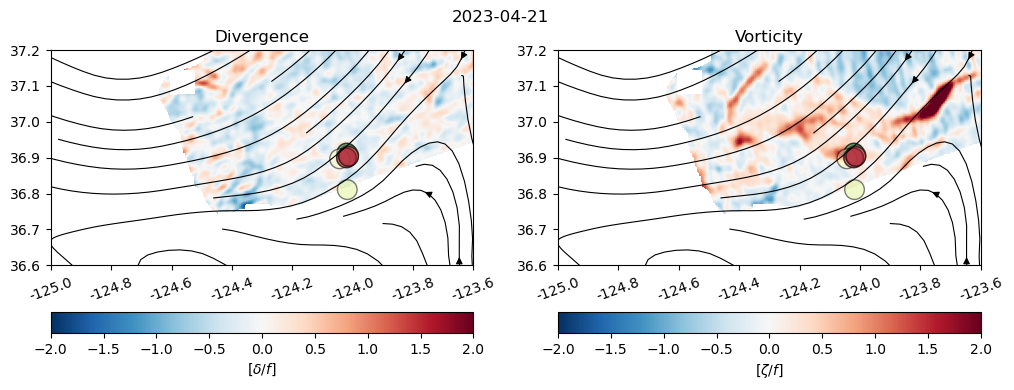

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)
/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)


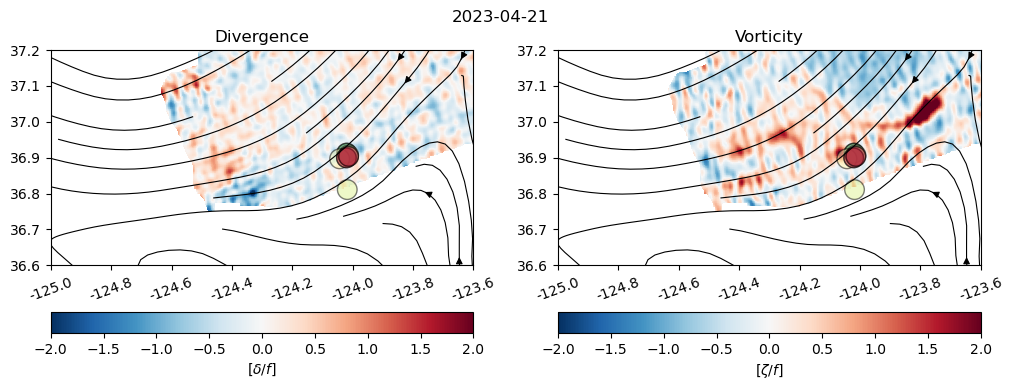

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)
/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)


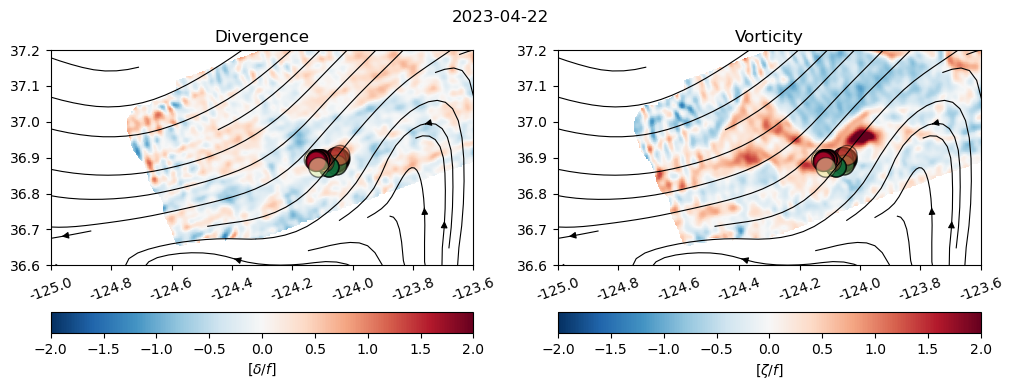

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)
/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)


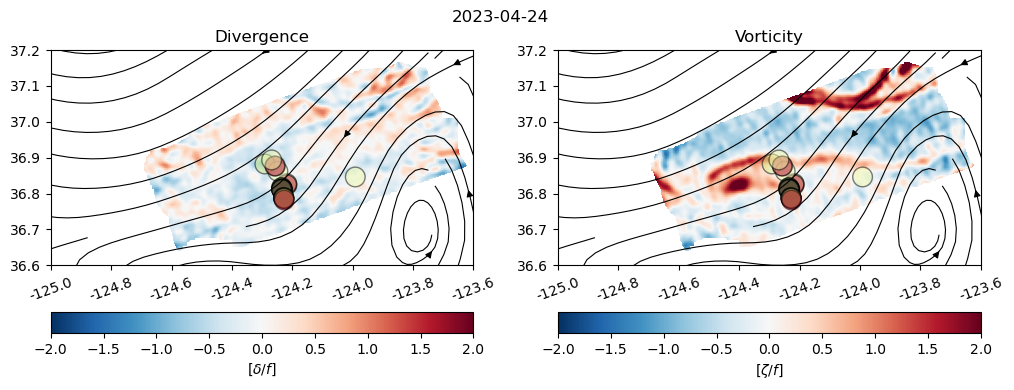

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)
/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)


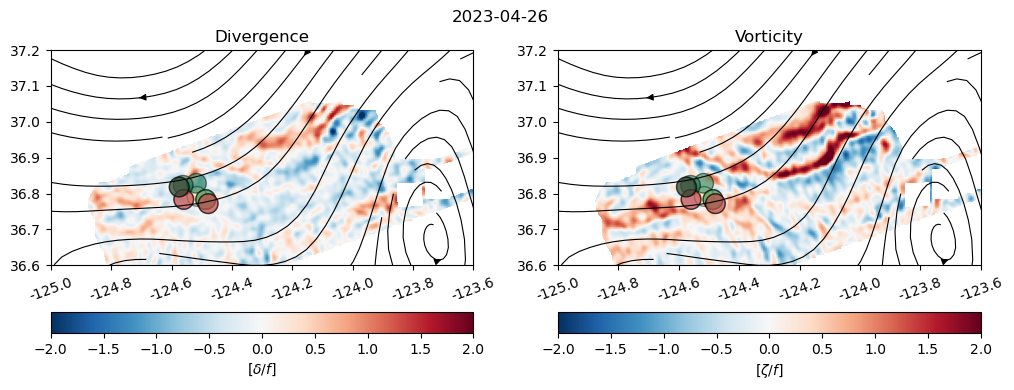

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)
/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)


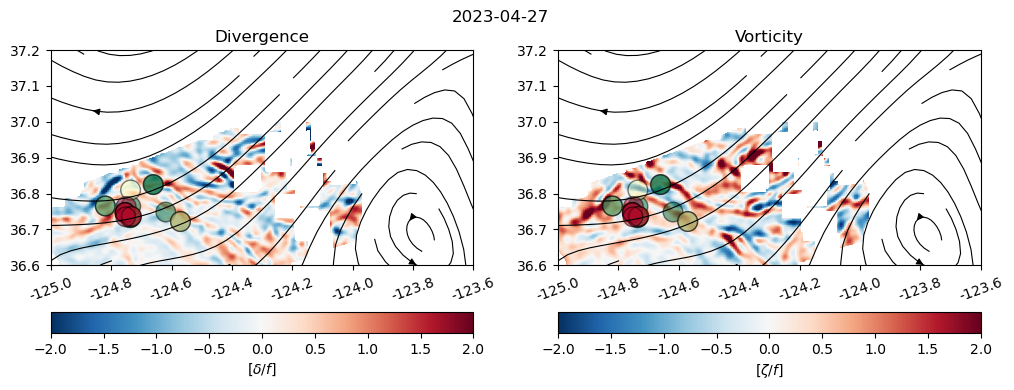

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)
/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43561/1447910195.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(axis.get_xticks(), rotation=20)


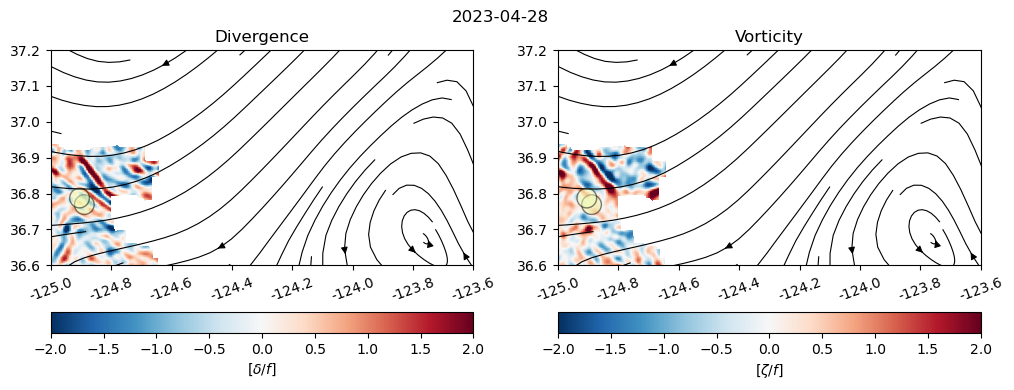

In [7]:
# with original files
import warnings
warnings.filterwarnings("ignore", message="The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing.")
warnings.filterwarnings("ignore", message="FixedFormatter should only be used together with FixedLocator")

for file in files[9:-1]:
    dopplerscatt = xr.open_dataset(file)
    f = coriolis_parameter(dopplerscatt.latitude.mean().values)
    time=str(dopplerscatt.mean_line_time.values[0])
    divergence, vorticity = kinematics(dopplerscatt)
    
    fig,ax=plt.subplots(1,2,figsize=(12,4))
    # divergence and vorticity
    p1=ax[0].pcolormesh(dopplerscatt.longitude,dopplerscatt.latitude,divergence/f,vmin=-2,vmax=2,cmap='RdBu_r')
    p2=ax[1].pcolormesh(dopplerscatt.longitude,dopplerscatt.latitude,vorticity/f,vmin=-2,vmax=2,cmap='RdBu_r')

    ax[0].set_title('Divergence')
    ax[1].set_title('Vorticity')
    plt.colorbar(p1,ax=ax[0],orientation='horizontal',label=r'[$\delta/f$]')
    plt.colorbar(p2,ax=ax[1],orientation='horizontal',label=r'[$\zeta/f$]')
    
    # add dChldt
    dChldt0=dChldt.sel(time=time[0:10])
    
    # add geostrophic contours
    ugos=geos.ugos.sel(time=time[0:10])
    vgos=geos.vgos.sel(time=time[0:10])
    geo_lons,geo_lats=np.meshgrid(geos.longitude,geos.latitude) 
    
    for axis in ax:
        axis.scatter(dChldt0.lon,dChldt0.lat,s=200,c=dChldt0.dChldt,edgecolor='k',cmap='RdYlGn',vmin=-1e-4,vmax=1e-4,alpha=0.5)
        axis.streamplot(geo_lons,geo_lats,ugos,vgos,color='k',density=5,linewidth=0.8,arrowsize=1)
        #axis.set_xlim(-125,-123.5); axis.set_ylim(36.6,37.2)
        axis.set_xlim(-125,-123.6); axis.set_ylim(36.6,37.2) #zoom
        axis.set_xticklabels(axis.get_xticks(), rotation=20)

    # save div/vor values under dChldt
    
        
    plt.suptitle(time[0:10])
    plt.show(); plt.close()

In [15]:
from scipy.interpolate import griddata

# Define the regular grid
x_new = np.linspace(-126, -122, 1000)
y_new = np.linspace(36, 38, 1000)
grid_x, grid_y = np.meshgrid(x_new, y_new)

interpolated_u = []
interpolated_v = []
interpolated_divergence = []
interpolated_vorticity = []
interpolated_okuboweiss = []
time_array = []

for file in files:
    # Open the dataset
    dopplerscatt = xr.open_dataset(file)
    u = dopplerscatt.u_current_all_lines.values
    v = dopplerscatt.v_current_all_lines.values
    
    # Compute divergence and vorticity
    W, divergence, vorticity = kinematics(dopplerscatt)

    # Perform interpolation
    x, y = dopplerscatt.longitude.values, dopplerscatt.latitude.values
    grid_u = griddata((x.flatten(), y.flatten()), u.flatten(), (grid_x, grid_y), method='nearest')
    grid_v = griddata((x.flatten(), y.flatten()), v.flatten(), (grid_x, grid_y), method='nearest')
    grid_div = griddata((x.flatten(), y.flatten()), divergence.flatten(), (grid_x, grid_y), method='nearest')
    grid_vor = griddata((x.flatten(), y.flatten()), vorticity.flatten(), (grid_x, grid_y), method='nearest')
    grid_ow = griddata((x.flatten(), y.flatten()), W.flatten(), (grid_x, grid_y), method='nearest')
    
    # Append interpolated DataArrays to the list
    interpolated_u.append(xr.DataArray(grid_u, dims=['lat', 'lon'], coords={'lat': y_new, 'lon': x_new}))
    interpolated_v.append(xr.DataArray(grid_v, dims=['lat', 'lon'], coords={'lat': y_new, 'lon': x_new}))
    interpolated_divergence.append(xr.DataArray(grid_div, dims=['lat', 'lon'], coords={'lat': y_new, 'lon': x_new}))
    interpolated_vorticity.append(xr.DataArray(grid_vor, dims=['lat', 'lon'], coords={'lat': y_new, 'lon': x_new}))
    interpolated_okuboweiss.append(xr.DataArray(grid_ow, dims=['lat', 'lon'], coords={'lat': y_new, 'lon': x_new}))
    
    time_array.append(str(dopplerscatt.mean_line_time.values[0]))

# Concatenate the DataArrays along the time dimension
interpolated_u = xr.concat(interpolated_u, dim='time')
interpolated_v = xr.concat(interpolated_v, dim='time')
interpolated_divergence = xr.concat(interpolated_divergence, dim='time')
interpolated_vorticity = xr.concat(interpolated_vorticity, dim='time')
interpolated_okuboweiss = xr.concat(interpolated_okuboweiss, dim='time')

# Create 'time' coordinate DataArray
time_coord = xr.DataArray(time_array, dims='time', name='time')
interpolated_u['time'] = time_coord
interpolated_v['time'] = time_coord
interpolated_divergence['time'] = time_coord
interpolated_vorticity['time'] = time_coord
interpolated_okuboweiss['time'] = time_coord

# combine all data
combined_dataset = xr.Dataset({
    'u': interpolated_u,
    'v': interpolated_v,
    'divergence': interpolated_divergence,
    'vorticity': interpolated_vorticity,
    'okuboweiss': interpolated_okuboweiss,
})

combined_dataset.to_netcdf('dopplerscatt_gridded.nc')

# Save the interpolated fields to NetCDF files
#interpolated_u.to_netcdf('interpolated_u.nc')
#interpolated_v.to_netcdf('interpolated_v.nc')
#interpolated_divergence.to_netcdf('interpolated_divergence.nc')
#interpolated_vorticity.to_netcdf('interpolated_vorticity.nc')

In [16]:
print('hello')

hello


<xarray.DataArray 'time' ()>
array('2023-04-17T10:22:13.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 2023-04-17T10:22:13
37.176232 -123.72116
37.17717717717718 -123.72172172172172


ValueError: x and y must have same first dimension, but have shapes (21,) and (1,)

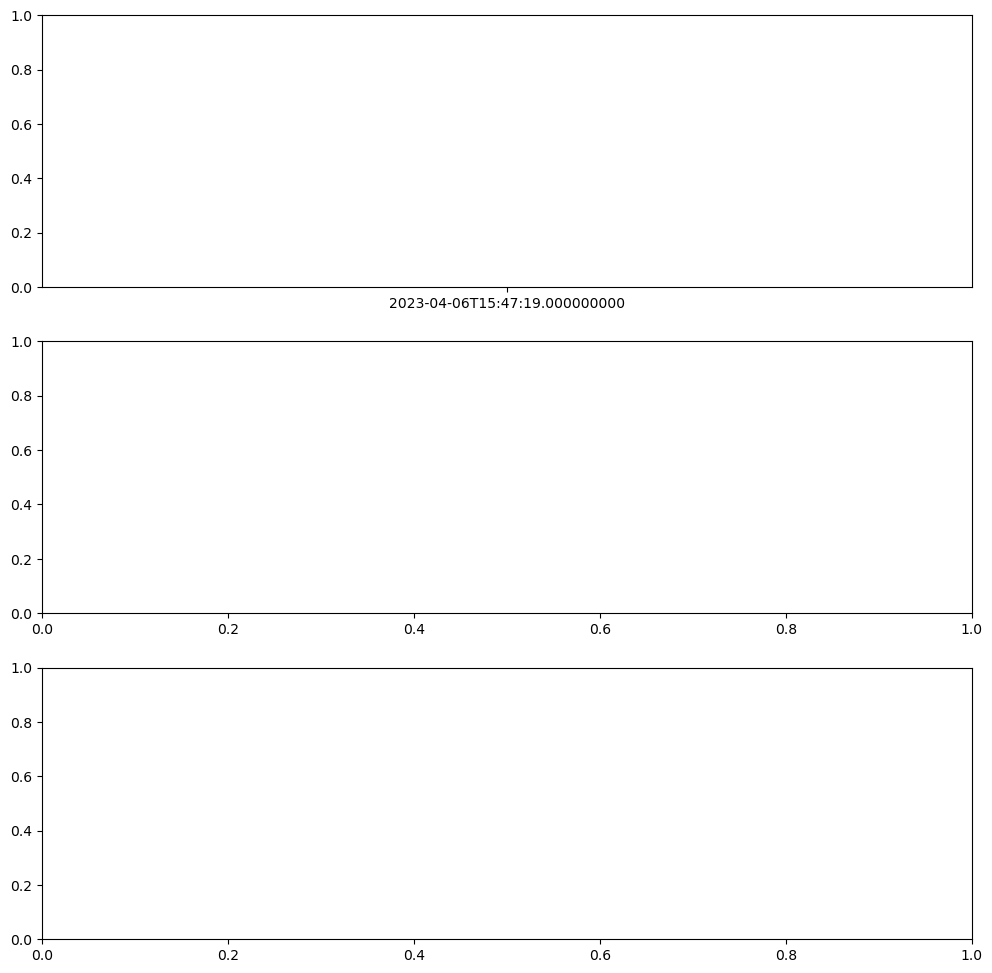

In [384]:
i=0
print(dChldt.isel(time=i).time)
dChldt_lat,dChldt_lon=dChldt.isel(time=i).lat.values, dChldt.isel(time=i).lon.values
print(dChldt_lat,dChldt_lon)
div_time = div.sel(lat=dChldt_lat,lon=dChldt_lon,method='nearest').time.values
div_lat = div.sel(lat=dChldt_lat,lon=dChldt_lon,method='nearest').lat.values
div_lon = div.sel(lat=dChldt_lat,lon=dChldt_lon,method='nearest').lon.values
print(div_lat,div_lon)

fig,ax = plt.subplots(3,1,figsize=(12,12))
#longitude plot
ax[0].plot(div_time,div_lon)
ax[0].plot(dChldt_time,dChldt_lat)
#latitude plot
ax[0].plot(div_time,div_lat)
ax[0].plot(dChldt_time,dChldt_lat)

In [374]:
div = xr.open_dataset('interpolated_divergence.nc')
vor = xr.open_dataset('interpolated_divergence.nc')
for i in range(len(dChldt.time)):
    div.sel(lat=dChldt.isel(time=i).lat, lon=dChldt.isel(time=i).lon, method='nearest').plot()


dChldt.dChldt.plot(linestyle='None',marker='.')

IndexError: dimension coordinate 'time' conflicts between indexed and indexing objects:
<xarray.DataArray 'time' (time: 21)>
array(['2023-04-06T15:47:19.000000000', '2023-04-07T20:22:56.000000000',
       '2023-04-08T15:51:32.000000000', '2023-04-10T20:43:28.000000000',
       '2023-04-11T20:07:26.000000000', '2023-04-12T20:38:29.000000000',
       '2023-04-13T19:35:52.000000000', '2023-04-14T20:02:01.000000000',
       '2023-04-15T17:57:23.000000000', '2023-04-17T20:15:18.000000000',
       '2023-04-18T20:45:55.000000000', '2023-04-19T20:25:05.000000000',
       '2023-04-20T20:45:06.000000000', '2023-04-21T15:21:25.000000000',
       '2023-04-21T21:28:58.000000000', '2023-04-22T20:10:41.000000000',
       '2023-04-24T20:15:37.000000000', '2023-04-26T21:07:49.000000000',
       '2023-04-27T20:07:57.000000000', '2023-04-28T21:45:05.000000000',
       '2023-04-29T18:37:18.000000000'], dtype='<U29')
Coordinates:
  * lat      float64 37.18
  * lon      float64 -123.7
  * time     (time) <U

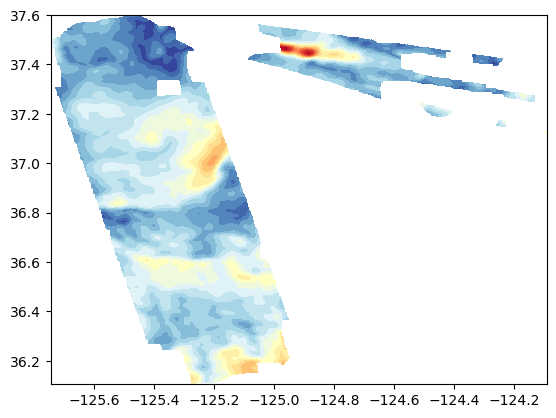

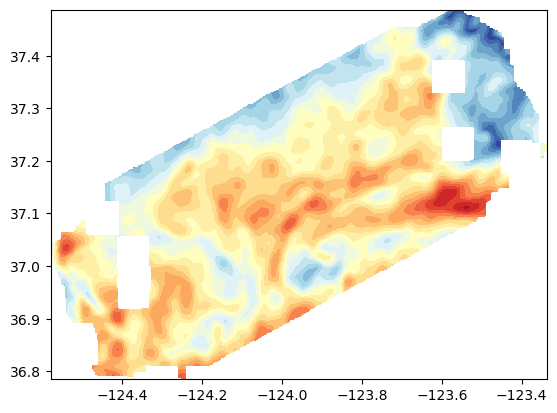

/Users/elise/miniconda3/lib/python3.10/site-packages/matplotlib/contour.py:1454: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/Users/elise/miniconda3/lib/python3.10/site-packages/matplotlib/contour.py:1455: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())


ValueError: zero-size array to reduction operation minimum which has no identity

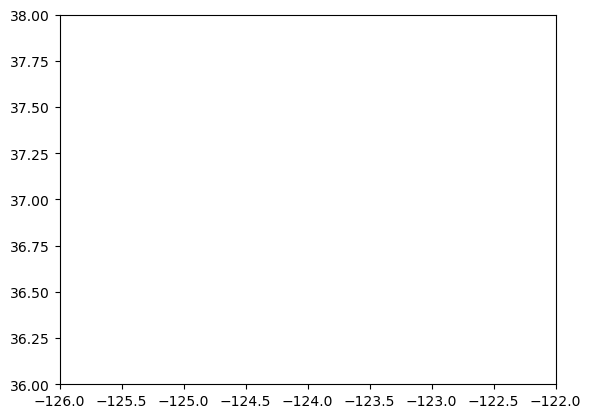

In [240]:
def grid_velocities(x,y,u,v,x_new,y_new):
    from scipy.interpolate import griddata
    x = x.values
    y = y.values
    u = u.values
    v = v.values

    # smooth
    delta_in = 200
    delta_out = 2000
    sigma_out = delta_out/np.sqrt(2*np.log(2))/2/delta_in
    u = scipy.ndimage.gaussian_filter(u,sigma_out)
    v = scipy.ndimage.gaussian_filter(v,sigma_out)
    
    grid_x, grid_y = np.meshgrid(x_new,y_new)
    grid_u = griddata((x.flatten(),y.flatten()), u.flatten(), (grid_x, grid_y), method='nearest')
    grid_v = griddata((x.flatten(),y.flatten()), v.flatten(), (grid_x, grid_y), method='nearest')
    return grid_u, grid_v

x_new = np.linspace(-126,-122,1000)
y_new = np.linspace(36,38,1000)

u_array = np.empty([len(files),len(x_new),len(y_new)])
v_array = np.empty([len(files),len(x_new),len(y_new)])
t_array = []

for i, file in enumerate(files):
    ds= xr.open_dataset(file)
    x = ds.longitude
    y = ds.latitude
    u = ds.u_current_all_lines
    v = ds.v_current_all_lines
    grid_u, grid_v = grid_velocities(x,y,u,v,x_new,y_new)
    
    plt.contourf(x_new,y_new,np.sqrt(grid_u**2+grid_v**2),20,cmap='RdYlBu_r')
    valid_indices = np.where(~np.isnan(grid_u))
    xmin, xmax = x_new[valid_indices[1]].min(), x_new[valid_indices[1]].max()
    ymin, ymax = y_new[valid_indices[0]].min(), y_new[valid_indices[0]].max()
    plt.xlim(xmin,xmax)
    plt.ylim(ymin,ymax)
    plt.show(); plt.close()

    # save in array
    u_array[i,...] = grid_u
    v_array[i,...] = grid_v
    t_array.append('2023-04-08T15:51:32.000000000')